# German Credit: explorative Datenanalyse

Dieses Notebook schaut sich den Datensatz an, bevor ein Modell trainiert wird.

Das Training steht nicht hier, sondern in `train.py` im Hauptordner.
Ein Notebook lässt sich nicht per Knopfdruck reproduzieren, ein Skript schon.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

COLUMNS = [
    "checking_status", "duration", "credit_history", "purpose",
    "credit_amount", "savings_account", "employment", "installment_rate",
    "personal_status", "other_debtors", "residence_since", "property",
    "age", "other_installment", "housing", "existing_credits",
    "job", "liable_people", "telephone", "foreign_worker",
    "risk",
]

df = pd.read_csv("../data/raw/german.data", sep=" ", header=None, names=COLUMNS)

# 1 = guter Kredit, 2 = Ausfall -> 0 / 1
df["risk"] = df["risk"] - 1

df.shape

(1000, 21)

## Erste Sicht

1000 Zeilen, 20 Merkmale, eine Zielvariable. Dreizehn Merkmale sind Text,
die kryptischen `A`-Codes des Datensatzes, sieben sind Zahlen.

In [2]:
print(df.dtypes.value_counts())
print()
print("Fehlende Werte:", df.isnull().sum().sum())

df.head(3)

object    13
int64      8
Name: count, dtype: int64

Fehlende Werte: 0


,checking_status,duration,credit_history,purpose,credit_amount,savings_account,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installment,housing,existing_credits,job,liable_people,telephone,foreign_worker,risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0


## Die Zielvariable ist schief verteilt

700 gute Kredite, 300 Ausfälle. Das klingt harmlos, hat aber eine Folge,
die man kennen muss.

In [3]:
counts = df["risk"].value_counts().sort_index()
print("gut    ", counts[0])
print("Ausfall", counts[1])
print()
print(f"Ein Modell, das immer 'gut' sagt, hätte {100 * counts[0] / len(df):.1f} % Accuracy.")

gut     700
Ausfall 300

Ein Modell, das immer 'gut' sagt, hätte 70.0 % Accuracy.


**Deshalb ist Accuracy hier fast wertlos.** Ein Modell ohne jede Intelligenz kommt
auf 70 Prozent, indem es die interessante Klasse ignoriert. Bewerten muss man über
Recall und Precision der Ausfall-Klasse, und besser noch über die Kosten dahinter.

Im Training wird die Schieflage über `scale_pos_weight` ausgeglichen: Ein übersehener
Ausfall zählt in der Fehlerrechnung 2,33-fach. Der Preis dafür ist, dass die
ausgegebenen Scores systematisch nach oben verschoben sind und keine
Ausfallwahrscheinlichkeiten mehr darstellen.

## Ausfallrate je Kategorie

Für jedes kategorische Merkmal: Wie hoch ist die tatsächliche Ausfallrate in jeder
seiner Ausprägungen, und auf wie vielen Fällen beruht sie?

Die Fallzahl ist dabei genauso wichtig wie die Rate. Eine auffällige Quote aus
40 Beobachtungen ist etwas anderes als dieselbe Quote aus 400.

In [4]:
categorical = [c for c in df.columns if df[c].dtype == "object"]

rows = []
for col in categorical:
    groupded = df.groupby(col)["risk"].agg(["mean", "count"])
    for code_value, (rate, n) in groupded.iterrows():
        rows.append({
            "merkmal": col,
            "code": code_value,
            "ausfallrate_%": round(100 * rate, 1),
            "fealle":int(n),
        })

rates = pd.DataFrame(rows)
rates

,merkmal,code,ausfallrate_%,fealle
0,checking_status,A11,49.3,274
1,checking_status,A12,39.0,269
2,checking_status,A13,22.2,63
3,checking_status,A14,11.7,394
4,credit_history,A30,62.5,40
5,credit_history,A31,57.1,49
6,credit_history,A32,31.9,530
7,credit_history,A33,31.8,88
8,credit_history,A34,17.1,293
9,purpose,A40,38.0,234


## Der auffälligste Fund: die Kredithistorie

Hier steht etwas, das der Intuition widerspricht.

In [5]:
history = df.groupby("credit_history")["risk"].agg(["mean", "count"])
history["ausfallrate_%"] = (100 * history["mean"]).round(1)

labels = {
    "A30": "keine Kredite aufgenommen / alle zurückgezahlt",
    "A31": "alle bei dieser Bank zurückgezahlt",
    "A32": "laufende Kredite pünktlich",
    "A33": "Zahlungsverzug in der Vergangenheit",
    "A34": "laufende Kredite bei anderen Banken",
}
history["bedeutung"] = [labels[i] for i in history.index]

history[["ausfallrate_%", "count", "bedeutung"]]

,ausfallrate_%,count,bedeutung
credit_history,,,
A30,62.5,40,keine Kredite aufgenommen / alle zurückgezahlt
A31,57.1,49,alle bei dieser Bank zurückgezahlt
A32,31.9,530,laufende Kredite pünktlich
A33,31.8,88,Zahlungsverzug in der Vergangenheit
A34,17.1,293,laufende Kredite bei anderen Banken


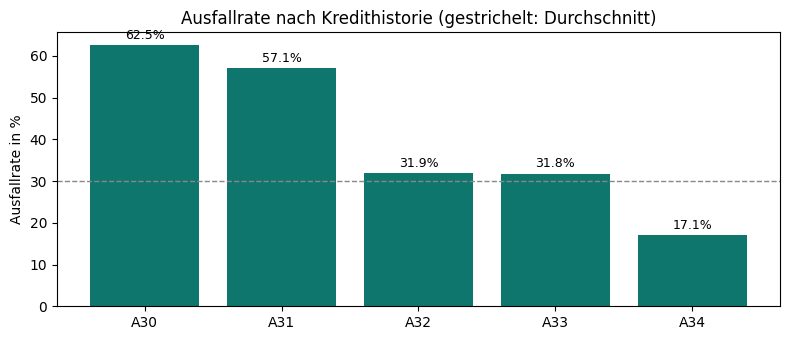

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))

ax.bar(history.index, history["ausfallrate_%"], color="#0f766e")
ax.axhline(30, color="#888", linestyle="--", linewidth=1)
ax.set_ylabel("Ausfallrate in %")
ax.set_title("Ausfallrate nach Kredithistorie (gestrichelt: Durchschnitt)")

for i, v in enumerate(history["ausfallrate_%"]):
    ax.text(i, v + 1.5, f"{v}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

**Wer noch nie einen Kredit hatte, fällt am häufigsten aus (62,5 %). Wer bereits
Zahlungsverzug hatte, deutlich seltener (31,8 %).**

Das ist kein Fehler in den Daten. Die ersten beiden Kategorien beschreiben Menschen
**ohne laufende Verbindlichkeit**, die letzten drei Menschen **mit** einer. In diesem
Datensatz ist ein laufender, bedienter Kredit ein gutes Zeichen: Irgendeine Bank hat
die Person bereits geprüft und für tragfähig befunden. Wer gar keine Kredithistorie
hat, ist für eine Bank nicht einschätzbar.

**Folge für das Projekt:** Im Demo-Widget hieß der Wert `A30` ursprünglich
„Alles pünktlich bezahlt". Besucher wählten das, erwarteten ein niedriges Risiko und
bekamen ein hohes. Die Beschriftung lautet jetzt „Noch keine Kredite aufgenommen",
beschreibt also, was der Wert bedeutet, statt ihn zu bewerten.

**Vorbehalt:** A30 und A31 beruhen auf nur 40 und 49 Fällen. Die Raten sind
entsprechend unsicher.

## Ordinal oder nominal?

Kategorische Merkmale werden für das Modell zu Zahlen. Die Frage ist, ob diese Zahlen
eine **Reihenfolge** tragen.

Bei `checking_status` ist das plausibel: von weniger Geld zu mehr Geld. Bei `purpose`
dagegen ist die Nummerierung alphabetisch entstanden und inhaltlich beliebig.

Ein einfacher Test: Läuft die Ausfallrate entlang der Nummerierung gleichmäßig hoch
oder runter, ist die Reihenfolge brauchbar. Springt sie hin und her, ist sie es nicht.

In [7]:
def is_monotonic(series):
    values = series.values
    return bool((values[1:] >= values[:-1]).all() or (values[1:] <= values[:-1]).all())

check = []
for col in categorical:
    grouped = df.groupby(col)["risk"].mean().sort_index()
    check.append({
        "merkmal": col,
        "kategorien": len(grouped),
        "spannweite_%": round(100 * (grouped.max() - grouped.min()), 1),
        "monoton": is_monotonic(grouped),
    })

pd.DataFrame(check).sort_values("spannweite_%", ascending=False).reset_index(drop=True)


,merkmal,kategorien,spannweite_%,monoton
0,credit_history,5,45.4,True
1,checking_status,4,37.6,True
2,purpose,10,32.9,False
3,other_debtors,3,24.7,False
4,savings_account,5,23.5,False
5,property,4,22.2,True
6,foreign_worker,2,19.9,True
7,employment,5,18.3,False
8,housing,3,14.7,False
9,other_installment,3,13.5,True


**Lesehilfe:** Die Spannweite sagt, wie viel bei diesem Merkmal überhaupt auf dem
Spiel steht. `monoton` sagt, ob die alphabetische Reihenfolge zufällig zur
Ausfallrate passt. Erst beides zusammen ergibt ein Bild.

- `credit_history` und `checking_status` haben große Spannweiten **und** eine
  passende Reihenfolge. Für sie ist die einfache Durchnummerierung ein Glücksfall.
- `purpose` hat eine große Spannweite, aber **keine** brauchbare Reihenfolge. Zehn
  Kategorien, deren riskanteste und harmloseste direkt nebeneinanderliegen.
- Bei kleiner Spannweite wie bei `job` ist die Frage praktisch bedeutungslos, weil
  das Merkmal ohnehin kaum etwas bewegt.
- Bei zweiwertigen Merkmalen wie `telephone` ist `monoton` immer wahr. Mit zwei
  Kategorien gibt es keine Reihenfolge, die falsch sein könnte. Der Test sagt dort
  also nichts aus.

**Folge für das Projekt:** Daraus entstand die Vermutung, dass One-Hot-Encoding
besser sein müsste. Sie wurde in `experiments/compare_encodings.py` gemessen und
widerlegt: Der Unterschied zwischen den drei Varianten liegt unterhalb der Streuung
zwischen verschiedenen Aufteilungen der Daten.

## Numerische Merkmale

Bei Zahlen lohnt der Blick auf Gruppen statt auf einzelne Werte.

In [8]:
df[["duration", "credit_amount", "age", "installment_rate"]].describe().round(1)

,duration,credit_amount,age,installment_rate
count,1000.0,1000.0,1000.0,1000.0
mean,20.9,3271.3,35.5,3.0
std,12.1,2822.7,11.4,1.1
min,4.0,250.0,19.0,1.0
25%,12.0,1365.5,27.0,2.0
50%,18.0,2319.5,33.0,3.0
75%,24.0,3972.2,42.0,4.0
max,72.0,18424.0,75.0,4.0


In [9]:
groups = {
    "Laufzeit (Monate)": pd.cut(df["duration"], [0, 12, 24, 36, 72]),
    "Kreditbetrag (€)": pd.cut(df["credit_amount"], [0, 2000, 5000, 10000, 20000]),
    "Alter (Jahre)": pd.cut(df["age"], [18, 25, 35, 50, 80]),
}

for title, grouping in groups.items():
    result = df.groupby(grouping, observed=True)["risk"].agg(["mean", "count"])
    result["ausfallrate_%"] = (100 * result["mean"]).round(1)
    print(title)
    print(result[["ausfallrate_%", "count"]].to_string())
    print()

Laufzeit (Monate)
          ausfallrate_%  count
duration                      
(0, 12]            21.2    359
(12, 24]           29.7    411
(24, 36]           39.9    143
(36, 72]           51.7     87

Kreditbetrag (€)
                ausfallrate_%  count
credit_amount                       
(0, 2000]                28.0    432
(2000, 5000]             26.6    380
(5000, 10000]            36.5    148
(10000, 20000]           60.0     40

Alter (Jahre)
          ausfallrate_%  count
age                           
(18, 25]           42.1    190
(25, 35]           29.6    398
(35, 50]           23.7    299
(50, 80]           27.4    113



Die Laufzeit verhält sich sauber: Von unter 12 auf über 36 Monate steigt die
Ausfallrate von 21 auf 52 Prozent, also auf das Zweieinhalbfache.

Beim Kreditbetrag greift der Zusammenhang erst oben. Zwischen 0 und 5000 Euro liegt
die Rate flach bei rund 27 Prozent, darüber steigt sie deutlich, bis auf 60 Prozent
jenseits von 10.000. Nur beruht dieser letzte Wert auf 40 Fällen.

Beim Alter fallen die Jüngsten klar heraus, 42 Prozent unter 25. Danach sinkt die
Rate und steigt bei den über 50-Jährigen wieder leicht an.

Nichts davon ist überraschend, aber es bestätigt, dass die Daten in sich schlüssig
sind. Und es zeigt, dass ein einfacher Zusammenhang wie „mehr Geld gleich mehr
Risiko" nur abschnittsweise gilt. Das ist einer der Gründe, warum ein Baum-Modell
hier besser passt als ein lineares.

## Die Kostenmatrix

`german.doc` enthält eine Angabe, die in vielen Auswertungen dieses Datensatzes
untergeht:

> Einen schlechten Kredit als gut einzustufen kostet **5**.
> Einen guten Kredit als schlecht einzustufen kostet **1**.

Damit ist die Frage, ab welchem Score ein Antrag abgelehnt wird, keine statistische
mehr, sondern eine Rechnung mit Preisschildern. Der voreingestellte Schnitt bei 0.5
unterstellt gleich teure Fehler und ist hier nachweislich falsch.

Hergeleitet wird die Schwelle in `experiments/find_thresholds.py`.

## Was daraus folgt

| Fund | Konsequenz im Projekt |
|---|---|
| 70/30-Schieflage | `scale_pos_weight` im Training, Accuracy als Kennzahl verworfen |
| Kredithistorie invertiert | Beschriftungen im Widget beschreiben statt bewerten |
| `purpose` ohne sinnvolle Reihenfolge | Encoding-Varianten gemessen statt vermutet |
| Kostenmatrix 5:1 | Entscheidungsschwellen hergeleitet, drei Risikozonen statt zwei |

Weiter geht es in `train.py` und in `experiments/`.